📍 Thư mục đang chạy ô code: d:\YELLOWTAXI-NYC2021\Data\src\ML
📂 Đường dẫn chốt cuối cùng: D:/YELLOWTAXI-NYC2021/Data/processed/KPI_requirements/kpi_daily_2021.csv
✅ Thành công! Đã nạp xong 365 dòng dữ liệu vào biến 'df'.
📊 Tổng số ngày dữ liệu: 365
   - Train: 351 ngày (Kết thúc: 2021-12-17)
   - Test:  14 ngày (Bắt đầu: 2021-12-18)
🚀 Đang huấn luyện mô hình Random Forest Regressor...

🔍 KẾT QUẢ ĐÁNH GIÁ THỰC TẾ VS RANDOM FOREST (14 NGÀY TEST)
MAE  (Sai số tuyệt đối): 27,537 chuyến/ngày
MAPE (Sai số phần trăm): 43.64%
⚠️ Đánh giá: Cần cải thiện tham số (<30%)

🔮 Đang dự báo cho 14 ngày tiếp theo (Chưa có dữ liệu)...

--- DỰ BÁO NHU CẦU 5 NGÀY TỚI ---
          ds           yhat    yhat_lower     yhat_upper
0 2022-01-01  115082.615685  87545.708771  142619.522598
1 2022-01-02   97242.973625  69706.066712  124779.880538
2 2022-01-03  100838.998125  73302.091212  128375.905038
3 2022-01-04  110486.485611  82949.578698  138023.392525
4 2022-01-05  114671.737461  87134.830548  142208.644375

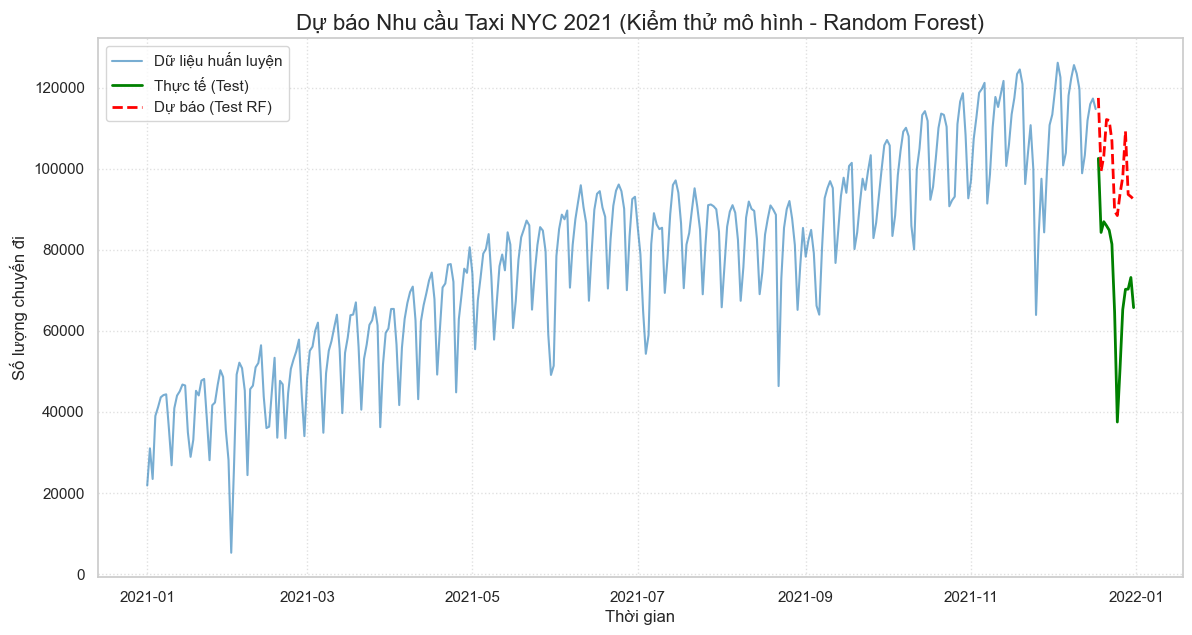

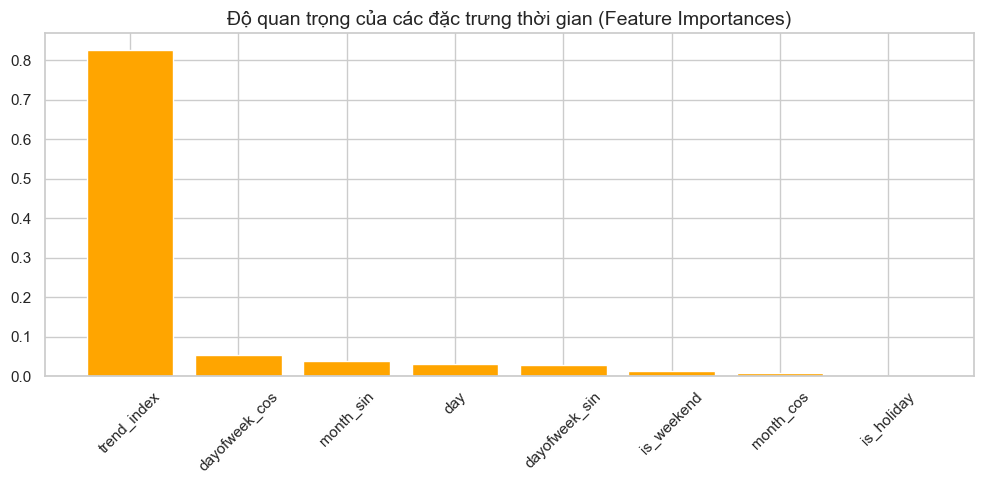


🎉 HOÀN TẤT CHUYỂN ĐỔI! Hãy kiểm tra các file ảnh mới trong thư mục 'figures'.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import holidays
import os

CURRENT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
print(f"📍 Thư mục đang chạy ô code: {CURRENT_DIR}")

# 2. Định vị đường dẫn tương đối an toàn
PATH_ATTEMPT_1 = os.path.abspath(os.path.join(CURRENT_DIR, "..", "..", "Data", "processed", "KPI_requirements", "kpi_daily_2021.csv"))
PATH_ATTEMPT_2 = os.path.abspath(os.path.join(CURRENT_DIR, "Data", "processed", "KPI_requirements", "kpi_daily_2021.csv"))

if os.path.exists(PATH_ATTEMPT_1):
    FULL_PATH = PATH_ATTEMPT_1
elif os.path.exists(PATH_ATTEMPT_2):
    FULL_PATH = PATH_ATTEMPT_2
else:
    FULL_PATH = "D:/YELLOWTAXI-NYC2021/Data/processed/KPI_requirements/kpi_daily_2021.csv"

print(f"📂 Đường dẫn chốt cuối cùng: {FULL_PATH}")

# 4. Kiểm tra sự tồn tại và đọc dữ liệu
if not os.path.exists(FULL_PATH):
    print("❌ LỖI: Bản kiểm tra cứng vẫn không tìm thấy file. Bạn hãy check lại tên file kpi_daily_2021.csv nhé!")
else:
    try:
        df = pd.read_csv(FULL_PATH)
        print(f"✅ Thành công! Đã nạp xong {len(df):,} dòng dữ liệu vào biến 'df'.")
    except Exception as e:
        print(f"❌ Lỗi khi nạp dữ liệu: {e}")

# =========================================================
# 2. TIỀN XỬ LÝ DỮ LIỆU & TẠO ĐẶC TRƯNG (FEATURE ENGINEERING)
# =========================================================
df_model = df[['pickup_date', 'trips']].rename(columns={'pickup_date': 'ds', 'trips': 'y'})
df_model['ds'] = pd.to_datetime(df_model['ds'])
df_model = df_model.sort_values('ds').reset_index(drop=True)

# Hàm tạo tính năng thời gian mô phỏng lại cấu trúc của Prophet
us_holidays = holidays.US(years=[2021, 2022]) # Tạo danh sách ngày lễ US

def create_time_features(data):
    df_feat = data.copy()
    # Xu hướng tuyến tính dài hạn (thay thế cho Trend của Prophet)
    df_feat['trend_index'] = (df_feat['ds'] - df_feat['ds'].min()).dt.days
    
    # Thành phần mùa vụ (Seasonality)
    df_feat['dayofweek'] = df_feat['ds'].dt.dayofweek
    df_feat['month'] = df_feat['ds'].dt.month
    df_feat['day'] = df_feat['ds'].dt.day
    df_feat['is_weekend'] = df_feat['dayofweek'].isin([5, 6]).astype(int)
    
    # Biến chu kỳ sin/cos để học máy hiểu tính chất vòng lặp tốt hơn
    df_feat['dayofweek_sin'] = np.sin(2 * np.pi * df_feat['dayofweek'] / 7.0)
    df_feat['dayofweek_cos'] = np.cos(2 * np.pi * df_feat['dayofweek'] / 7.0)
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12.0)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12.0)
    
    # Thành phần ngày lễ (Holidays)
    df_feat['is_holiday'] = df_feat['ds'].isin(us_holidays).astype(int)
    
    return df_feat

# Tạo tập dữ liệu đầy đủ các đặc trưng
df_features = create_time_features(df_model)

# Danh sách các cột đặc trưng dùng để huấn luyện mô hình
feature_cols = ['trend_index', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'day', 'is_weekend', 'is_holiday']

# Chia tập Train và Test (GIỮ NGUYÊN kết quả phân chia dữ liệu cũ)
TEST_DAYS = 14
train_df = df_features.iloc[:-TEST_DAYS]
test_df = df_features.iloc[-TEST_DAYS:]

X_train, y_train = train_df[feature_cols], train_df['y']
X_test, y_test = test_df[feature_cols], test_df['y']

print(f"📊 Tổng số ngày dữ liệu: {len(df_model)}")
print(f"   - Train: {len(train_df)} ngày (Kết thúc: {train_df['ds'].max().date()})")
print(f"   - Test:  {len(test_df)} ngày (Bắt đầu: {test_df['ds'].min().date()})")

# =========================================================
# 3. HUÂN LUYỆN MÔ HÌNH RANDOM FOREST
# =========================================================
# Tinh chỉnh các tham số quan trọng:
# n_estimators=200: Tăng số lượng cây giúp mô hình mượt mà hơn
# max_depth=10, min_samples_split=4: Tránh Overfitting trong chuỗi thời gian biến động 2021
# random_state=42: Cố định kết quả ngẫu nhiên để tái tạo kết quả sau mỗi lần chạy

model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)

print("🚀 Đang huấn luyện mô hình Random Forest Regressor...")
model_rf.fit(X_train, y_train)

# =========================================================
# 4. ĐÁNH GIÁ MÔ HÌNH (EVALUATION)
# =========================================================
# Dự báo trên tập Test
y_pred = model_rf.predict(X_test)
y_true = y_test.values

mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("\n" + "="*40)
print("🔍 KẾT QUẢ ĐÁNH GIÁ THỰC TẾ VS RANDOM FOREST (14 NGÀY TEST)")
print("="*40)
print(f"MAE  (Sai số tuyệt đối): {mae:,.0f} chuyến/ngày")
print(f"MAPE (Sai số phần trăm): {mape*100:.2f}%")

if mape < 0.1:
    print("🌟 Đánh giá: Mô hình RẤT TỐT (<10%)")
elif mape < 0.2:
    print("✅ Đánh giá: Mô hình TỐT (<20%)")
else:
    print("⚠️ Đánh giá: Cần cải thiện tham số (<30%)")

# =========================================================
# 5. DỰ BÁO TƯƠNG LAI & XUẤT KẾT QUẢ
# =========================================================
print("\n🔮 Đang dự báo cho 14 ngày tiếp theo (Chưa có dữ liệu)...")
last_date = df_model['ds'].max()

# Tạo khung thời gian cho 14 ngày SAU KHI hết dữ liệu trong file giống như cũ
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=TEST_DAYS)
future_df = pd.DataFrame({'ds': future_dates})

# Áp dụng hàm trích xuất tính năng cho dữ liệu tương lai
# Đặc biệt: Ta tính toán trend_index dựa trên gốc thời gian cũ để tiếp tục xu hướng tuyến tính
future_df['trend_index'] = (future_df['ds'] - df_model['ds'].min()).dt.days
future_df['dayofweek'] = future_df['ds'].dt.dayofweek
future_df['month'] = future_df['ds'].dt.month
future_df['day'] = future_df['ds'].dt.day
future_df['is_weekend'] = future_df['dayofweek'].isin([5, 6]).astype(int)
future_df['dayofweek_sin'] = np.sin(2 * np.pi * future_df['dayofweek'] / 7.0)
future_df['dayofweek_cos'] = np.cos(2 * np.pi * future_df['dayofweek'] / 7.0)
future_df['month_sin'] = np.sin(2 * np.pi * future_df['month'] / 12.0)
future_df['month_cos'] = np.cos(2 * np.pi * future_df['month'] / 12.0)
future_df['is_holiday'] = future_df['ds'].isin(us_holidays).astype(int)

# Dự đoán tương lai bằng mô hình Random Forest đã train
future_df['yhat'] = model_rf.predict(future_df[feature_cols])

# Do Random Forest không tự tính khoảng tin cậy (yhat_lower, yhat_upper) tự động như Prophet,
# chúng ta tạo cận biên giả định dựa trên Sai số Tuyệt đối Trung bình (MAE) để bảo toàn cấu trúc bảng in ra.
future_df['yhat_lower'] = future_df['yhat'] - mae
future_df['yhat_upper'] = future_df['yhat'] + mae

print("\n--- DỰ BÁO NHU CẦU 5 NGÀY TỚI ---")
print(future_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(5))

# =========================================================
# 6. TRỰC QUAN HÓA CHUYÊN SÂU (VISUALIZATION)
# =========================================================
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- BIỂU ĐỒ 1: SO KHỚP THỰC TẾ VS DỰ BÁO ---
plt.figure(figsize=(14, 7))
plt.plot(train_df['ds'], train_df['y'], label='Dữ liệu huấn luyện', color='#1f77b4', alpha=0.6)
plt.plot(test_df['ds'], test_df['y'], label='Thực tế (Test)', color='green', linewidth=2)
plt.plot(test_df['ds'], y_pred, label='Dự báo (Test RF)', color='red', linestyle='--', linewidth=2)
plt.title('Dự báo Nhu cầu Taxi NYC 2021 (Kiểm thử mô hình - Random Forest)', fontsize=16)
plt.xlabel('Thời gian')
plt.ylabel('Số lượng chuyến đi')
plt.legend()    
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(os.path.join(FIGURES_DIR, 'forecast_evaluation_rf.png'), dpi=150)
print(f"\n✅ Đã lưu biểu đồ đánh giá tại folder {FIGURES_DIR}")
plt.show()

# --- BIỂU ĐỒ 2: ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (Đã sửa lỗi) ---
plt.figure(figsize=(10, 5))

# 1. Sửa lỗi: Thêm dấu gạch dưới (_) và bỏ cặp ngoặc đơn ()
importances = model_rf.feature_importances_ 

# 2. Đồng bộ danh sách tính năng phù hợp với số lượng mảng importances
if len(importances) == len(feature_cols):
    current_features = feature_cols
else:
    # Trường hợp phòng hờ bạn đổi sang danh sách biến khác
    current_features = [f"Feature {i}" for i in range(len(importances))]

indices = np.argsort(importances)[::-1]

# 3. Tiến hành vẽ đồ thị thanh
plt.bar(range(len(current_features)), importances[indices], color='orange', align='center')
plt.xticks(range(len(current_features)), [current_features[i] for i in indices], rotation=45)
plt.title('Độ quan trọng của các đặc trưng thời gian (Feature Importances)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'forecast_feature_importances.png'), dpi=150)
plt.show()

print("\n🎉 HOÀN TẤT CHUYỂN ĐỔI! Hãy kiểm tra các file ảnh mới trong thư mục 'figures'.")